**PROJECT OVERVIEW**

* Project by Jedidah Wavinya
* Date: 16th March 2026
* Project Title: Web Scraping Data from a bookstore website
* Data to scrape:
1. Book title
2. Price
3. Rating
4. Stock availability
5. Category
6. Product description

1. Install Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import bs4
from bs4 import BeautifulSoup

2. Connect to the Website

In [2]:
# provide the link to the website containing the data to be scrapped.
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

# the respomse "200" means that the connection has worked.

200


3. Parse the HTML

In [3]:
soup = BeautifulSoup(response.text, "html.parser")
# This takes the raw HTML content obtained from the website.
# This soup object then allows you to navigate and search the HTML document easily to extract the desired data.

4. Extract the book containe: article class="product_pod"

In [4]:
books = soup.find_all("article", class_="product_pod")

print(len(books))
# You should see 20 books per page. Confirm the output

20


5. Extract Book Data

In [5]:
titles = []
prices = []
ratings = []
availability_list = []
links = []

# These lists are created to act as containers where the scraped data for each book will be stored.
# As the program iterates through the books found on the website, it will extract the respective title, price, rating, availability, and link for each book and append them to their corresponding list.
# This allows for easy collection and organization of the data before further processing, such as creating a DataFrame.

6. Loop through books:

In [6]:
for book in books:

    title = book.h3.a["title"]

    price = book.find("p", class_="price_color").text

    availability = book.find("p", class_="instock availability").text.strip()

    rating = book.p["class"][1]

    link = book.h3.a["href"]
    link = "https://books.toscrape.com/" + link

    titles.append(title)
    prices.append(price)
    ratings.append(rating)
    availability_list.append(availability)
    links.append(link)

7. Convert to DataFrame

In [7]:
df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings,
    "Availability": availability_list,
    "Product_URL": links
})

In [8]:
df.head()

,Title,Price,Rating,Availability,Product_URL
0,A Light in the Attic,Â£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


Scrape Multiple Pages

In [9]:
titles = []
prices = []
ratings = []
availability_list = []
links = []

for page in range(1, 51):

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:

        title = book.h3.a["title"]

        price = book.find("p", class_="price_color").text

        availability = book.find("p", class_="instock availability").text.strip()

        rating = book.p["class"][1]

        link = book.h3.a["href"]
        link = "https://books.toscrape.com/catalogue/" + link

        titles.append(title)
        prices.append(price)
        ratings.append(rating)
        availability_list.append(availability)
        links.append(link)

Create Final Dataset

In [10]:
df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings,
    "Availability": availability_list,
    "Product_URL": links
})

df.head()

,Title,Price,Rating,Availability,Product_URL
0,A Light in the Attic,Â£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


Clean the Price Column

In [11]:
df['Price'] = df['Price'].str.replace('Â£', '').astype(float)

Convert Rating to Numbers

In [12]:
rating_map = {
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5
}

df["Rating"] = df["Rating"].map(rating_map)

Save Dataset


In [13]:
df.to_csv("books_dataset.csv", index=False)

Basic Analysis

In [14]:
df["Price"].mean()

np.float64(35.07035)

In [15]:
df.sort_values(by="Price", ascending=False).head(10)

,Title,Price,Rating,Availability,Product_URL
648,The Perfect Play (Play by Play #1),59.99,3,In stock,https://books.toscrape.com/catalogue/the-perfe...
617,Last One Home (New Beginnings #1),59.98,3,In stock,https://books.toscrape.com/catalogue/last-one-...
860,Civilization and Its Discontents,59.95,2,In stock,https://books.toscrape.com/catalogue/civilizat...
560,The Barefoot Contessa Cookbook,59.92,5,In stock,https://books.toscrape.com/catalogue/the-baref...
366,The Diary of a Young Girl,59.90,3,In stock,https://books.toscrape.com/catalogue/the-diary...
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3,In stock,https://books.toscrape.com/catalogue/the-bone-...
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1,In stock,https://books.toscrape.com/catalogue/thomas-je...
387,Boar Island (Anna Pigeon #19),59.48,3,In stock,https://books.toscrape.com/catalogue/boar-isla...
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,In stock,https://books.toscrape.com/catalogue/the-man-w...
393,The Improbability of Love,59.45,1,In stock,https://books.toscrape.com/catalogue/the-impro...


In [16]:
df["Rating"].value_counts()

,count
Rating,
1,226
3,203
5,196
2,196
4,179


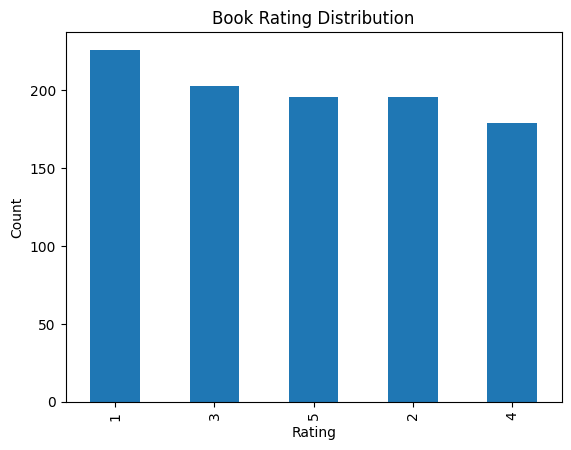

In [17]:
import matplotlib.pyplot as plt

df["Rating"].value_counts().plot(kind="bar")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()